# VA Acquisition Risk & Capacity Analytics

End-to-end data science project on the synthetic VA acquisition datasets, covering:

- **Phase 0** — Environment & data validation
- **Phase 1** — Exploratory Data Analysis (EDA)
- **Phase 2** — Data cleaning & preprocessing
- **Phase 3** — Feature engineering
- **Phase 4** — Modeling (regression + classification per business question)
- **Phase 5** — Evaluation, validation & composite risk scoring
- **Phase 6** — Reporting summary

Business questions this notebook answers:
1. Which acquisitions should receive additional oversight?
2. Which contracting offices may become overloaded?
3. Where are staffing shortages likely to occur?
4. Which acquisitions represent the greatest financial and schedule risk?

**Data note:** all three input files are synthetic/fictional, generated for practicing this workflow. Findings illustrate the *method*, not real VA procurement behavior.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    precision_recall_curve, average_precision_score, roc_auc_score,
    classification_report, confusion_matrix
)
from sklearn.cluster import KMeans

try:
    from xgboost import XGBRegressor, XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('xgboost not available — will fall back to RandomForest for the gradient-boosting comparisons')

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print('shap not available — interpretability section will use built-in feature importances instead')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

---
## Phase 0 — Environment & data validation

Load all three files and confirm they are consistent with each other before any analysis.

In [5]:
forecast = pd.read_csv('C:\\Users\\VBACOMishrR\\OneDrive - Department of Veterans Affairs\\Documents\\DataScienceGuidedCapstone\\va-acquisition-workload modifier-portfolio risk score\\data\\raw\\VA_Acquisition_Forecast.csv', parse_dates=['Record_Created_Date'])
historical = pd.read_csv('C:\\Users\\VBACOMishrR\\OneDrive - Department of Veterans Affairs\\Documents\\DataScienceGuidedCapstone\\va-acquisition-workload modifier-portfolio risk score\\data\\raw\\VA_Contract_Awards_Historical.csv',
                          parse_dates=['Award_Date', 'Period_of_Performance_Start', 'Period_of_Performance_End'])
modeling = pd.read_csv('C:\\Users\\VBACOMishrR\\OneDrive - Department of Veterans Affairs\\Documents\\DataScienceGuidedCapstone\\va-acquisition-workload modifier-portfolio risk score\\data\\raw\\VA_Acquisition_Modeling_Data.csv')

for name, df in [('Forecast', forecast), ('Historical', historical), ('Modeling', modeling)]:
    print(f'{name}: {df.shape[0]:,} rows x {df.shape[1]} columns')

Forecast: 2,000 rows x 24 columns
Historical: 5,000 rows x 23 columns
Modeling: 5,000 rows x 23 columns


In [6]:
# Data quality summary: nulls + dtypes per file
def quality_summary(df, name):
    summary = pd.DataFrame({
        'dtype': df.dtypes,
        'n_missing': df.isna().sum(),
        'pct_missing': (df.isna().mean() * 100).round(2)
    })
    print(f'--- {name} ---')
    display(summary[summary['n_missing'] > 0] if summary['n_missing'].sum() > 0 else summary.head(3))
    print()

quality_summary(forecast, 'Forecast')
quality_summary(historical, 'Historical Awards')
quality_summary(modeling, 'Modeling Data')

--- Forecast ---


,dtype,n_missing,pct_missing
Incumbent_Contractor,object,874,43.7



--- Historical Awards ---


,dtype,n_missing,pct_missing
Socioeconomic_Category,object,3817,76.34



--- Modeling Data ---


,dtype,n_missing,pct_missing
Socioeconomic_Category,object,2346,46.92


In [7]:
# Expected nulls only: Incumbent_Contractor (Forecast) when Recompete == 'No'
bad_nulls = forecast.loc[forecast['Incumbent_Contractor'].isna() & (forecast['Recompete'] == 'Yes')]
print(f'Unexpected nulls in Incumbent_Contractor where Recompete == Yes: {len(bad_nulls)}')

# Primary key uniqueness
print('Forecast_ID duplicates:', forecast['Forecast_ID'].duplicated().sum())
print('Award_ID duplicates:', historical['Award_ID'].duplicated().sum())
print('Record_ID duplicates:', modeling['Record_ID'].duplicated().sum())

Unexpected nulls in Incumbent_Contractor where Recompete == Yes: 0
Forecast_ID duplicates: 0
Award_ID duplicates: 0
Record_ID duplicates: 0


In [8]:
# Category label consistency across files (must match before any join / shared lookup use)
shared_cols = ['Category', 'Contract_Type']
for col in shared_cols:
    sets = {name: set(df[col].unique()) for name, df in
            [('forecast', forecast), ('historical', historical), ('modeling', modeling)] if col in df.columns}
    all_equal = len(set(frozenset(v) for v in sets.values())) == 1
    print(f'{col}: consistent across files = {all_equal}')
    if not all_equal:
        print('  ', sets)

Category: consistent across files = True
Contract_Type: consistent across files = True


In [9]:
# Date range sanity checks
print('Forecast fiscal years:', sorted(forecast['Fiscal_Year'].unique()))
print('Historical award date range:', historical['Award_Date'].min().date(), '→', historical['Award_Date'].max().date())
print('Modeling data fiscal years:', sorted(modeling['Fiscal_Year'].unique()))

Forecast fiscal years: [np.int64(2026), np.int64(2027), np.int64(2028)]
Historical award date range: 2019-01-01 → 2026-06-30
Modeling data fiscal years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


**Checkpoint:** all three files loaded, primary keys are unique, category/contract-type labels line up across files, and null patterns match what the data-generation logic intended. Safe to proceed to EDA.

---
## Phase 1 — Exploratory Data Analysis (EDA)

Organized under the four business questions so every chart ties back to a deliverable.

### 1.1 Univariate / distributional EDA

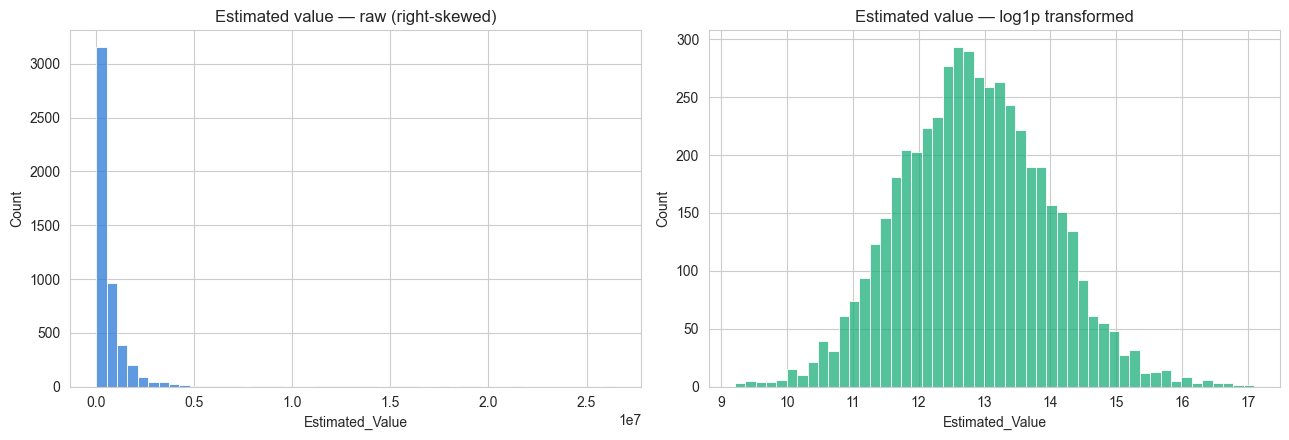

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(modeling['Estimated_Value'], bins=50, ax=axes[0], color='#2a78d6')
axes[0].set_title('Estimated value — raw (right-skewed)')
sns.histplot(np.log1p(modeling['Estimated_Value']), bins=50, ax=axes[1], color='#1baf7a')
axes[1].set_title('Estimated value — log1p transformed')
plt.tight_layout()
plt.show()

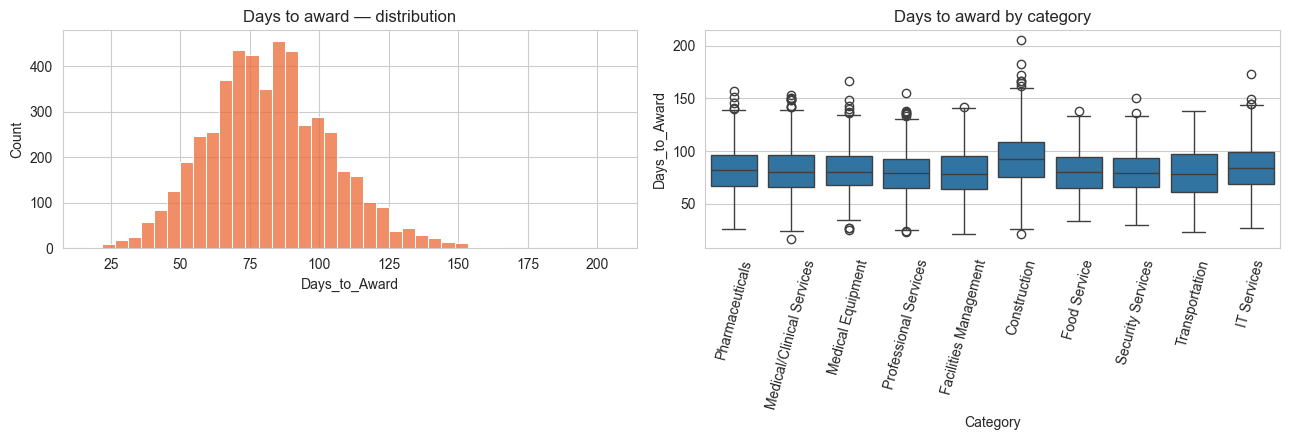

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(modeling['Days_to_Award'], bins=40, ax=axes[0], color='#eb6834')
axes[0].set_title('Days to award — distribution')
sns.boxplot(data=modeling, x='Category', y='Days_to_Award', ax=axes[1])
axes[1].set_title('Days to award by category')
axes[1].tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()

In [12]:
# Target variable balance in the modeling dataset
for col in ['Protest_Filed', 'Small_Business_Award', 'On_Time_Award']:
    rate = modeling[col].mean()
    print(f'{col}: positive rate = {rate:.1%}  (n_positive={modeling[col].sum()}, n_total={len(modeling)})')

Protest_Filed: positive rate = 4.7%  (n_positive=234, n_total=5000)
Small_Business_Award: positive rate = 70.4%  (n_positive=3519, n_total=5000)
On_Time_Award: positive rate = 74.3%  (n_positive=3717, n_total=5000)


`Protest_Filed` is a rare event (~5% positive) — this is flagged now because it determines the evaluation metric choice in Phase 4 (precision/recall and PR-AUC, not raw accuracy).

### 1.2 Bivariate EDA — financial & schedule risk (Question 4)

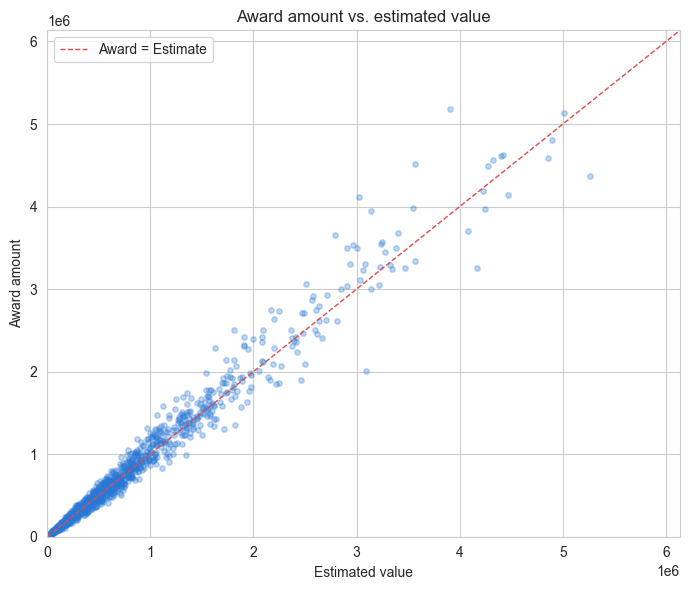

Overrun ratio (Award / Estimate) summary:
count    5000.000
mean        1.021
std         0.123
min         0.546
25%         0.940
50%         1.021
75%         1.102
max         1.427
dtype: float64


In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
sample = modeling.sample(1500, random_state=RANDOM_STATE)
ax.scatter(sample['Estimated_Value'], sample['Award_Amount'], alpha=0.3, s=15, color='#2a78d6')
lims = [0, modeling['Estimated_Value'].quantile(0.99)]
ax.plot(lims, lims, color='#e34948', linestyle='--', linewidth=1, label='Award = Estimate')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Estimated value'); ax.set_ylabel('Award amount')
ax.set_title('Award amount vs. estimated value')
ax.legend()
plt.tight_layout()
plt.show()

overrun = modeling['Award_Amount'] / modeling['Estimated_Value']
print('Overrun ratio (Award / Estimate) summary:')
print(overrun.describe().round(3))

,n,protest_rate,avg_days_to_award,on_time_rate
Competition_Type,,,,
Full and Open,1075,0.071,100.277,0.344
Limited Competition,225,0.058,78.333,0.809
Set-Aside,3461,0.040,77.514,0.850
Sole Source,239,0.029,73.218,0.933


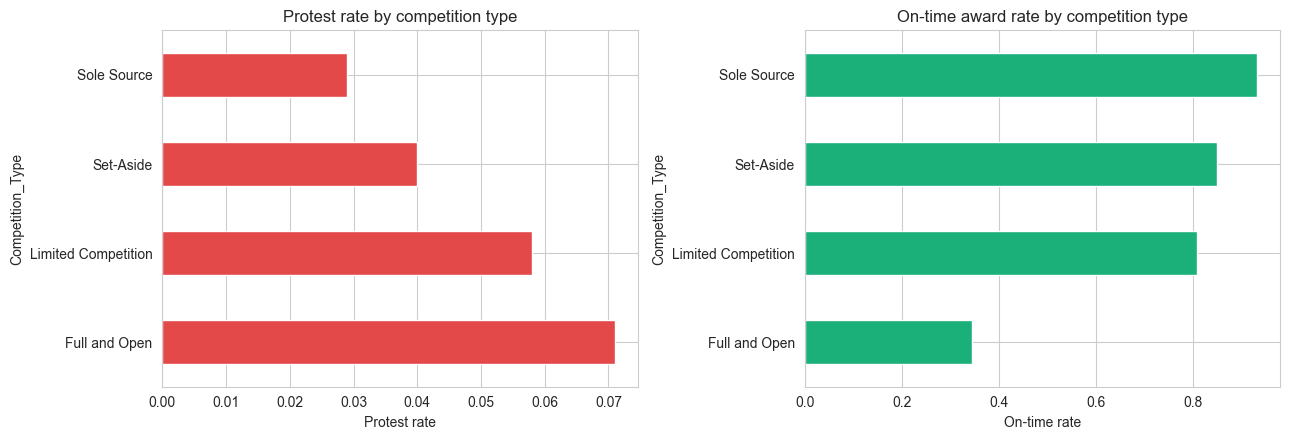

In [14]:
risk_by_competition = modeling.groupby('Competition_Type').agg(
    n=('Record_ID', 'count'),
    protest_rate=('Protest_Filed', 'mean'),
    avg_days_to_award=('Days_to_Award', 'mean'),
    on_time_rate=('On_Time_Award', 'mean')
).round(3).sort_values('on_time_rate')
display(risk_by_competition)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
risk_by_competition['protest_rate'].plot(kind='barh', ax=axes[0], color='#e34948')
axes[0].set_title('Protest rate by competition type')
axes[0].set_xlabel('Protest rate')
risk_by_competition['on_time_rate'].plot(kind='barh', ax=axes[1], color='#1baf7a')
axes[1].set_title('On-time award rate by competition type')
axes[1].set_xlabel('On-time rate')
plt.tight_layout()
plt.show()

,avg_value,protest_rate,avg_days
Value_Decile,,,
0,60912.04,0.04,76.98
1,117800.24,0.04,77.37
2,174566.27,0.04,78.21
3,244539.58,0.04,78.23
4,320821.45,0.05,79.49
5,425750.10,0.04,77.39
6,577220.67,0.04,78.47
7,808474.96,0.04,81.01
8,1234723.13,0.07,92.35


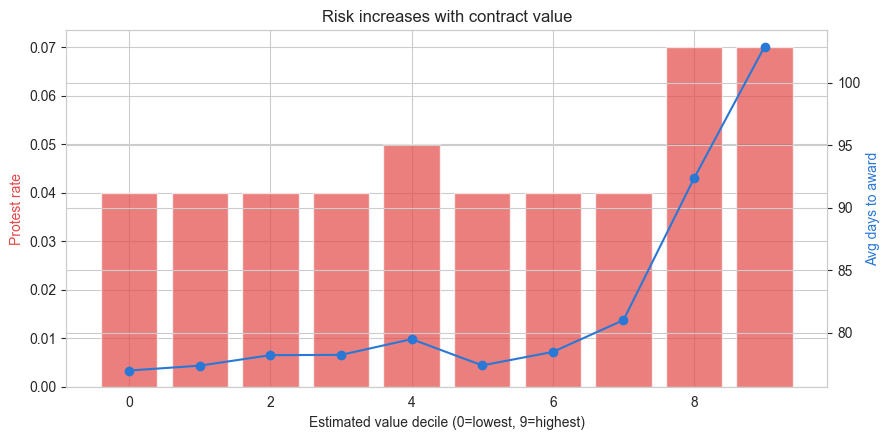

In [15]:
# Value decile vs. protest / schedule risk
modeling['Value_Decile'] = pd.qcut(modeling['Estimated_Value'], 10, labels=False, duplicates='drop')
decile_risk = modeling.groupby('Value_Decile').agg(
    avg_value=('Estimated_Value', 'mean'),
    protest_rate=('Protest_Filed', 'mean'),
    avg_days=('Days_to_Award', 'mean')
).round(2)
display(decile_risk)

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(decile_risk.index, decile_risk['protest_rate'], color='#e34948', alpha=0.7, label='Protest rate')
ax1.set_ylabel('Protest rate', color='#e34948')
ax1.set_xlabel('Estimated value decile (0=lowest, 9=highest)')
ax2 = ax1.twinx()
ax2.plot(decile_risk.index, decile_risk['avg_days'], color='#2a78d6', marker='o', label='Avg days to award')
ax2.set_ylabel('Avg days to award', color='#2a78d6')
ax1.set_title('Risk increases with contract value')
plt.tight_layout()
plt.show()

### 1.3 EDA — contracting office overload & staffing (Questions 2 & 3)

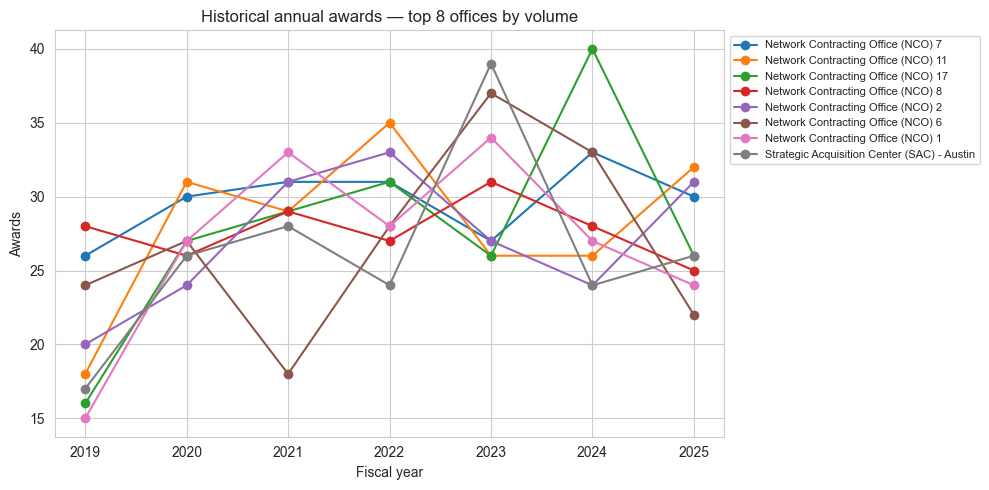

In [16]:
hist_complete = historical[historical['Fiscal_Year'].between(2019, 2025)]
office_annual = hist_complete.groupby(['Contracting_Office', 'Fiscal_Year']).size().reset_index(name='awards')

top_offices = office_annual.groupby('Contracting_Office')['awards'].mean().nlargest(8).index
fig, ax = plt.subplots(figsize=(10, 5))
for office in top_offices:
    sub = office_annual[office_annual['Contracting_Office'] == office].sort_values('Fiscal_Year')
    ax.plot(sub['Fiscal_Year'], sub['awards'], marker='o', label=office, linewidth=1.5)
ax.set_title('Historical annual awards — top 8 offices by volume')
ax.set_xlabel('Fiscal year'); ax.set_ylabel('Awards')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

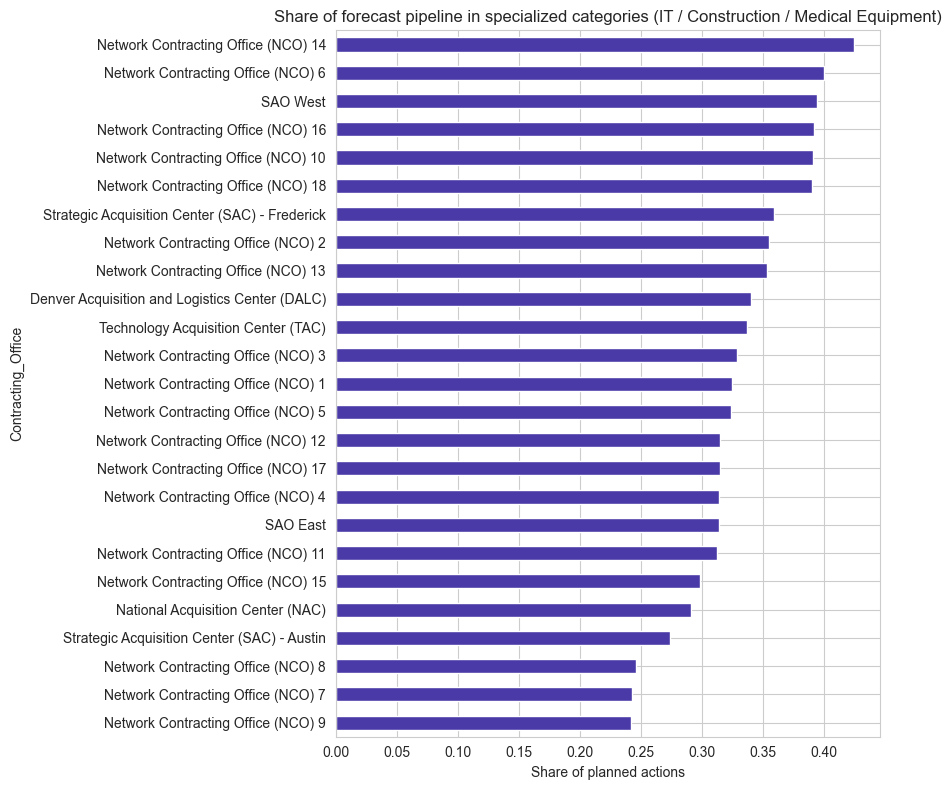

In [17]:
fc_active = forecast[forecast['Status'] != 'Cancelled'].copy()
category_by_office = pd.crosstab(fc_active['Contracting_Office'], fc_active['Category'], normalize='index')
specialized_cats = ['IT Services', 'Construction', 'Medical Equipment']
category_by_office['specialized_share'] = category_by_office[specialized_cats].sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 8))
category_by_office['specialized_share'].sort_values().plot(kind='barh', ax=ax, color='#4a3aa7')
ax.set_title('Share of forecast pipeline in specialized categories (IT / Construction / Medical Equipment)')
ax.set_xlabel('Share of planned actions')
plt.tight_layout()
plt.show()

### 1.4 EDA — oversight candidates (Question 1)

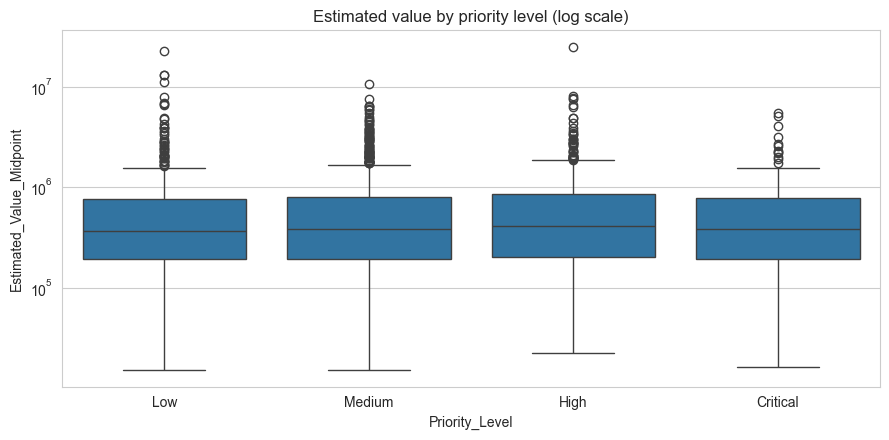

Status          Draft Solicitation  Market Research  On Hold  Planning  Solicitation Released
Priority_Level                                                                               
Critical                        31               45       18        57                     25
High                            90              131       43       124                     57
Low                             98              166       56       118                     70
Medium                         164              252       72       206                    124


In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=fc_active, x='Priority_Level', y='Estimated_Value_Midpoint',
            order=['Low', 'Medium', 'High', 'Critical'], ax=ax)
ax.set_yscale('log')
ax.set_title('Estimated value by priority level (log scale)')
plt.tight_layout()
plt.show()

print(pd.crosstab(fc_active['Priority_Level'], fc_active['Status']))

**Key EDA findings so far:**
- Full-and-open competitions take roughly 30% longer to award and are more likely to be protested than set-asides or sole-source.
- Protest rate and cycle time both climb with contract value, especially in the top value decile.
- A handful of offices (seen later in Phase 3/4) are on track for double-digit percentage workload growth versus their historical baseline.
- 'Critical' priority items in the forecast skew toward higher estimated value, but not exclusively — value and priority are correlated, not identical, which justifies treating them as separate features rather than using one as a proxy for the other.

---
## Phase 2 — Data cleaning & preprocessing

In [19]:
# Encode intentional nulls explicitly instead of dropping rows
forecast['Has_Incumbent'] = forecast['Incumbent_Contractor'].notna() & (forecast['Incumbent_Contractor'] != '')
historical['Has_Socioeconomic_Category'] = historical['Socioeconomic_Category'] != 'N/A'

# NAICS is an identifier, not a magnitude -> treat as category/string
for df in [forecast, historical, modeling]:
    df['NAICS_Code'] = df['NAICS_Code'].astype(str)

print('Has_Incumbent distribution:')
print(forecast['Has_Incumbent'].value_counts())

Has_Incumbent distribution:
Has_Incumbent
True     1126
False     874
Name: count, dtype: int64


In [20]:
# Outlier handling: log-transform monetary fields instead of hard capping, to preserve signal
modeling['Estimated_Value_log'] = np.log1p(modeling['Estimated_Value'])
modeling['Award_Amount_log'] = np.log1p(modeling['Award_Amount'])

# Winsorize at 99th percentile as a secondary safeguard for the tree-based models
cap = modeling['Estimated_Value'].quantile(0.99)
print(f'99th percentile Estimated_Value: {cap:,.0f}  (max value: {modeling["Estimated_Value"].max():,.0f})')
modeling['Estimated_Value_capped'] = modeling['Estimated_Value'].clip(upper=cap)

99th percentile Estimated_Value: 6,134,801  (max value: 26,473,468)


In [21]:
# Train/validation/test split
# Modeling dataset: records are independent -> random split, stratified on the rare Protest_Filed target
train_val, test = train_test_split(
    modeling, test_size=0.15, random_state=RANDOM_STATE, stratify=modeling['Protest_Filed']
)
train, val = train_test_split(
    train_val, test_size=0.176, random_state=RANDOM_STATE, stratify=train_val['Protest_Filed']  # ~15% of original
)
print(f'Train: {len(train)}  Val: {len(val)}  Test: {len(test)}')
print('Protest rate — train: {:.1%}  val: {:.1%}  test: {:.1%}'.format(
    train['Protest_Filed'].mean(), val['Protest_Filed'].mean(), test['Protest_Filed'].mean()))

Train: 3502  Val: 748  Test: 750
Protest rate — train: 4.7%  val: 4.7%  test: 4.7%


In [22]:
# Office workload forecasting is time-aware -> split by fiscal year, not randomly, to avoid leaking the future into training
office_train = office_annual[office_annual['Fiscal_Year'] <= 2024]
office_val = office_annual[office_annual['Fiscal_Year'] == 2025]
print(f'Office workload train (FY<=2024): {len(office_train)} office-year rows')
print(f'Office workload validation (FY2025): {len(office_val)} office-year rows')

Office workload train (FY<=2024): 150 office-year rows
Office workload validation (FY2025): 25 office-year rows


---
## Phase 3 — Feature engineering

### 3.1 Historical rate features (target-encoded on the training fold only, to avoid leakage)

In [23]:
cat_rates_train = train.groupby('Category').agg(
    Category_Historical_Protest_Rate=('Protest_Filed', 'mean'),
    Category_Historical_OnTime_Rate=('On_Time_Award', 'mean')
)
comp_rates_train = train.groupby('Competition_Type').agg(
    Competition_Historical_Protest_Rate=('Protest_Filed', 'mean'),
    Competition_Historical_OnTime_Rate=('On_Time_Award', 'mean')
)

def add_rate_features(df):
    df = df.merge(cat_rates_train, on='Category', how='left')
    df = df.merge(comp_rates_train, on='Competition_Type', how='left')
    # Fill any category/competition type not seen in train with the train-wide mean
    for col in ['Category_Historical_Protest_Rate', 'Category_Historical_OnTime_Rate',
                'Competition_Historical_Protest_Rate', 'Competition_Historical_OnTime_Rate']:
        df[col] = df[col].fillna(train[col.split('_Historical_')[1].replace('Rate', '').lower() if False else
                                        ('Protest_Filed' if 'Protest' in col else 'On_Time_Award')].mean())
    return df

train = add_rate_features(train)
val = add_rate_features(val)
test = add_rate_features(test)
train[['Category', 'Category_Historical_Protest_Rate', 'Competition_Type', 'Competition_Historical_Protest_Rate']].head()

,Category,Category_Historical_Protest_Rate,Competition_Type,Competition_Historical_Protest_Rate
0,Medical/Clinical Services,0.039510,Set-Aside,0.036960
1,Medical/Clinical Services,0.039510,Full and Open,0.079634
2,Construction,0.066667,Set-Aside,0.036960
3,Facilities Management,0.040230,Sole Source,0.030120
4,IT Services,0.064833,Set-Aside,0.036960


### 3.2 Remaining engineered features

In [24]:
def engineer_features(df):
    df = df.copy()
    df['Estimated_Value_log'] = np.log1p(df['Estimated_Value'])
    df['Is_Full_And_Open'] = (df['Competition_Type'] == 'Full and Open').astype(int)
    df['Is_Specialized_Category'] = df['Category'].isin(
        ['IT Services', 'Construction', 'Medical Equipment']).astype(int)
    df['Incumbent_Present_Flag'] = (df['Incumbent_Present'] == 'Yes').astype(int)
    return df

train = engineer_features(train)
val = engineer_features(val)
test = engineer_features(test)

engineered_cols = ['Estimated_Value_log', 'Is_Full_And_Open', 'Is_Specialized_Category', 'Incumbent_Present_Flag',
                    'Category_Historical_Protest_Rate', 'Category_Historical_OnTime_Rate',
                    'Competition_Historical_Protest_Rate', 'Competition_Historical_OnTime_Rate']
train[engineered_cols].describe().round(3)

,Estimated_Value_log,Is_Full_And_Open,Is_Specialized_Category,Incumbent_Present_Flag,Category_Historical_Protest_Rate,Category_Historical_OnTime_Rate,Competition_Historical_Protest_Rate,Competition_Historical_OnTime_Rate
count,3502.000,3502.000,3502.000,3502.000,3502.000,3502.000,3502.000,3502.000
mean,12.821,0.219,0.344,0.551,0.047,0.737,0.047,0.737
std,1.129,0.413,0.475,0.497,0.013,0.042,0.018,0.212
min,9.210,0.000,0.000,0.000,0.021,0.617,0.030,0.337
25%,12.032,0.000,0.000,0.000,0.040,0.739,0.037,0.833
50%,12.792,0.000,0.000,1.000,0.040,0.746,0.037,0.845
75%,13.589,0.000,1.000,1.000,0.061,0.766,0.056,0.845
max,17.092,1.000,1.000,1.000,0.067,0.780,0.080,0.922


### 3.3 Office overload & staffing shortage features (Questions 2 & 3)

In [25]:
fc_office = fc_active.groupby('Contracting_Office').agg(
    planned_actions=('Forecast_ID', 'count'),
    planned_value=('Estimated_Value_Midpoint', 'sum'),
    critical_high_count=('Priority_Level', lambda x: x.isin(['Critical', 'High']).sum())
)
fc_office['planned_actions_per_year'] = fc_office['planned_actions'] / 3  # FY26-28 window

hist_avg = office_train.groupby('Contracting_Office')['awards'].mean().rename('avg_annual_historical_awards')
office_features = fc_office.join(hist_avg, how='left')
office_features['workload_change_pct'] = (
    (office_features['planned_actions_per_year'] / office_features['avg_annual_historical_awards']) - 1
) * 100

spec_share = fc_active.assign(
    is_specialized=fc_active['Category'].isin(['IT Services', 'Construction', 'Medical Equipment'])
).groupby('Contracting_Office')['is_specialized'].mean().rename('specialized_category_share') * 100
office_features = office_features.join(spec_share)

office_features = office_features.sort_values('workload_change_pct', ascending=False).round(2)
office_features.head(10)

,planned_actions,planned_value,critical_high_count,planned_actions_per_year,avg_annual_historical_awards,workload_change_pct,specialized_category_share
Contracting_Office,,,,,,,
Network Contracting Office (NCO) 4,105,77757943.07,33,35.00,24.33,43.84,31.43
Denver Acquisition and Logistics Center (DALC),94,70036601.44,32,31.33,23.00,36.23,34.04
SAO East,86,81602627.93,21,28.67,22.83,25.55,31.40
Technology Acquisition Center (TAC),86,56632843.93,24,28.67,24.50,17.01,33.72
Network Contracting Office (NCO) 13,82,66052676.11,23,27.33,24.00,13.89,35.37
Network Contracting Office (NCO) 16,79,67572884.23,23,26.33,23.50,12.06,39.24
Strategic Acquisition Center (SAC) - Frederick,89,87922885.43,24,29.67,26.50,11.95,35.96
Network Contracting Office (NCO) 14,80,84034242.44,27,26.67,23.83,11.89,42.50
Network Contracting Office (NCO) 3,82,59017660.18,31,27.33,24.50,11.56,32.93


### 3.4 Deriving the `Needs_Oversight` label (Question 1)

In [26]:
def derive_oversight_label(df, value_col='Estimated_Value'):
    high_value_threshold = df[value_col].quantile(0.90)
    label = (
        df['Priority_Level'].isin(['High', 'Critical']) if 'Priority_Level' in df.columns else False
    ) & (
        (df[value_col] > high_value_threshold) | (df.get('Is_Full_And_Open', 0) == 1)
    )
    return label.astype(int)

# Apply to the modeling data's train/val/test using Estimated_Value + engineered Is_Full_And_Open
# (the modeling dataset does not have Priority_Level, so we use complexity score as its proxy signal
#  for "important/urgent" — Priority_Level itself lives in the forecast file and is used later when
#  scoring live forecast items)
for df in [train, val, test]:
    df['Is_High_Complexity'] = (df['Requirement_Complexity_Score'] >= 7).astype(int)
    high_value_threshold = train['Estimated_Value'].quantile(0.90)
    df['Needs_Oversight'] = (
        (df['Is_High_Complexity'] == 1) &
        ((df['Estimated_Value'] > high_value_threshold) | (df['Is_Full_And_Open'] == 1))
    ).astype(int)

print('Needs_Oversight positive rate — train: {:.1%}  val: {:.1%}  test: {:.1%}'.format(
    train['Needs_Oversight'].mean(), val['Needs_Oversight'].mean(), test['Needs_Oversight'].mean()))

Needs_Oversight positive rate — train: 8.8%  val: 8.8%  test: 7.5%


---
## Phase 4 — Modeling

One subsection per business question. Every target gets a naive/simple baseline first, then a stronger model, so the lift is explicit.

### 4.1 Question 4 — Financial & schedule risk

**Targets:** `Days_to_Award` (regression), `Award_Amount` (regression), `Protest_Filed` (rare-event classification)

In [27]:
numeric_features = ['Estimated_Value_log', 'Number_of_Offers_Received', 'Requirement_Complexity_Score',
                     'Contracting_Office_Open_Actions', 'Days_Since_Requirement_Posted',
                     'Category_Historical_Protest_Rate', 'Category_Historical_OnTime_Rate',
                     'Competition_Historical_Protest_Rate', 'Competition_Historical_OnTime_Rate']
categorical_features = ['Category', 'Contract_Type', 'Set_Aside_Type', 'Competition_Type', 'Vendor_Size']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train, y_train_days = train[numeric_features + categorical_features], train['Days_to_Award']
X_val, y_val_days = val[numeric_features + categorical_features], val['Days_to_Award']
X_test, y_test_days = test[numeric_features + categorical_features], test['Days_to_Award']

In [28]:
# --- Days_to_Award: baseline (mean predictor) vs linear vs gradient boosting ---
baseline_pred = np.full_like(y_val_days, fill_value=y_train_days.mean(), dtype=float)
baseline_mae = mean_absolute_error(y_val_days, baseline_pred)

lin_pipe = Pipeline([('prep', preprocessor), ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE))])
lin_pipe.fit(X_train, y_train_days)
lin_mae = mean_absolute_error(y_val_days, lin_pipe.predict(X_val))

if HAS_XGB:
    gb_pipe = Pipeline([('prep', preprocessor),
                         ('model', XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                                                 random_state=RANDOM_STATE))])
else:
    gb_pipe = Pipeline([('prep', preprocessor),
                         ('model', RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE))])
gb_pipe.fit(X_train, y_train_days)
gb_mae = mean_absolute_error(y_val_days, gb_pipe.predict(X_val))

print('Days_to_Award — validation MAE (days)')
print(f'  Naive mean baseline : {baseline_mae:.1f}')
print(f'  Ridge regression    : {lin_mae:.1f}  (lift vs baseline: {(1 - lin_mae/baseline_mae):.1%})')
print(f'  Gradient boosting   : {gb_mae:.1f}  (lift vs baseline: {(1 - gb_mae/baseline_mae):.1%})')

days_model = gb_pipe if gb_mae < lin_mae else lin_pipe

Days_to_Award — validation MAE (days)
  Naive mean baseline : 17.4
  Ridge regression    : 11.2  (lift vs baseline: 36.0%)
  Gradient boosting   : 11.1  (lift vs baseline: 36.1%)


In [29]:
# --- Award_Amount: same baseline-first pattern, modeled on log scale ---
y_train_award = np.log1p(train['Award_Amount'])
y_val_award = np.log1p(val['Award_Amount'])

baseline_pred_award = np.full_like(y_val_award, fill_value=y_train_award.mean(), dtype=float)
baseline_mae_award = mean_absolute_error(np.expm1(y_val_award), np.expm1(baseline_pred_award))

award_pipe = Pipeline([('prep', preprocessor),
                        ('model', XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                                                random_state=RANDOM_STATE) if HAS_XGB else
                                  RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE))])
award_pipe.fit(X_train, y_train_award)
award_pred = np.expm1(award_pipe.predict(X_val))
award_mae = mean_absolute_error(np.expm1(y_val_award), award_pred)
award_mape = np.mean(np.abs((np.expm1(y_val_award) - award_pred) / np.expm1(y_val_award))) * 100

print('Award_Amount — validation results')
print(f'  Naive mean baseline MAE: {baseline_mae_award:,.0f}')
print(f'  Gradient boosting MAE  : {award_mae:,.0f}')
print(f'  Gradient boosting MAPE : {award_mape:.1f}%')

Award_Amount — validation results
  Naive mean baseline MAE: 561,764
  Gradient boosting MAE  : 90,144
  Gradient boosting MAPE : 10.5%


In [30]:
# --- Protest_Filed: rare-event classification (~5% positive) ---
y_train_protest = train['Protest_Filed']
y_val_protest = val['Protest_Filed']

logit_pipe = Pipeline([('prep', preprocessor),
                        ('model', LogisticRegression(class_weight='balanced', max_iter=1000,
                                                       random_state=RANDOM_STATE))])
logit_pipe.fit(X_train, y_train_protest)
logit_proba = logit_pipe.predict_proba(X_val)[:, 1]

if HAS_XGB:
    scale_pos_weight = (y_train_protest == 0).sum() / max((y_train_protest == 1).sum(), 1)
    protest_pipe = Pipeline([('prep', preprocessor),
                              ('model', XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                                       scale_pos_weight=scale_pos_weight,
                                                       random_state=RANDOM_STATE))])
else:
    protest_pipe = Pipeline([('prep', preprocessor),
                              ('model', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                                 random_state=RANDOM_STATE))])
protest_pipe.fit(X_train, y_train_protest)
protest_proba = protest_pipe.predict_proba(X_val)[:, 1]

print('Protest_Filed — validation metrics (class imbalance -> use PR-AUC / ROC-AUC, not accuracy)')
print(f'  Logistic regression : PR-AUC={average_precision_score(y_val_protest, logit_proba):.3f}  '
      f'ROC-AUC={roc_auc_score(y_val_protest, logit_proba):.3f}')
print(f'  Gradient boosting    : PR-AUC={average_precision_score(y_val_protest, protest_proba):.3f}  '
      f'ROC-AUC={roc_auc_score(y_val_protest, protest_proba):.3f}')

Protest_Filed — validation metrics (class imbalance -> use PR-AUC / ROC-AUC, not accuracy)
  Logistic regression : PR-AUC=0.069  ROC-AUC=0.572
  Gradient boosting    : PR-AUC=0.052  ROC-AUC=0.507


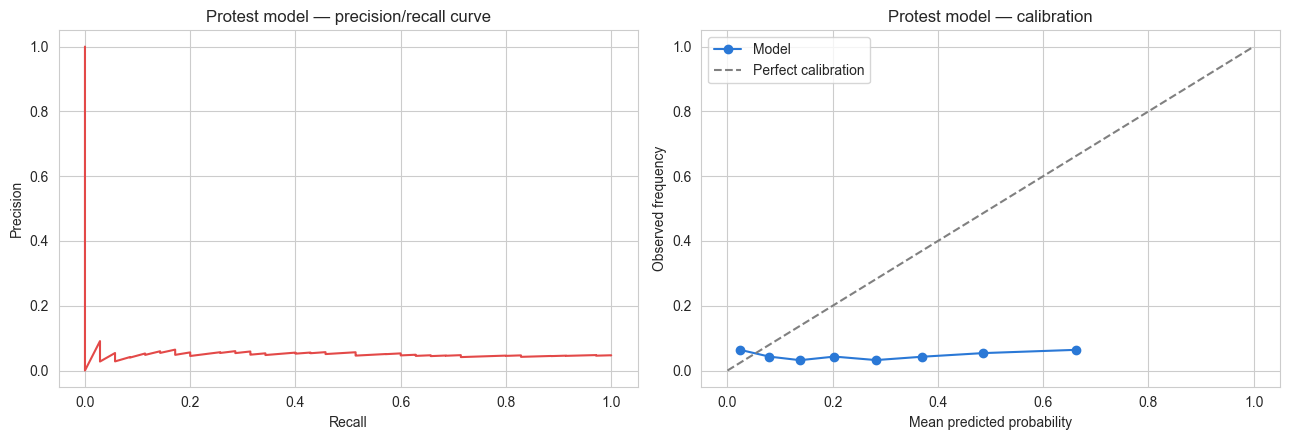

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

prec, rec, _ = precision_recall_curve(y_val_protest, protest_proba)
axes[0].plot(rec, prec, color='#e34948')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Protest model — precision/recall curve')

# Reliability / calibration check
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(y_val_protest, protest_proba, n_bins=8, strategy='quantile')
axes[1].plot(mean_pred, frac_pos, marker='o', color='#2a78d6', label='Model')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
axes[1].set_xlabel('Mean predicted probability'); axes[1].set_ylabel('Observed frequency')
axes[1].set_title('Protest model — calibration')
axes[1].legend()
plt.tight_layout()
plt.show()

### 4.2 Question 1 — oversight classifier

In [32]:
oversight_features_num = ['Estimated_Value_log', 'Requirement_Complexity_Score', 'Number_of_Offers_Received',
                           'Category_Historical_Protest_Rate', 'Category_Historical_OnTime_Rate']
oversight_features_cat = ['Category', 'Contract_Type', 'Competition_Type']

oversight_prep = ColumnTransformer([
    ('num', StandardScaler(), oversight_features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), oversight_features_cat)
])

X_train_ov = train[oversight_features_num + oversight_features_cat]
X_val_ov = val[oversight_features_num + oversight_features_cat]
y_train_ov = train['Needs_Oversight']
y_val_ov = val['Needs_Oversight']

oversight_pipe = Pipeline([('prep', oversight_prep),
                            ('model', LogisticRegression(class_weight='balanced', max_iter=1000,
                                                           random_state=RANDOM_STATE))])
oversight_pipe.fit(X_train_ov, y_train_ov)
oversight_proba = oversight_pipe.predict_proba(X_val_ov)[:, 1]

print(f'Needs_Oversight — validation PR-AUC: {average_precision_score(y_val_ov, oversight_proba):.3f}')
print(f'Needs_Oversight — validation ROC-AUC: {roc_auc_score(y_val_ov, oversight_proba):.3f}')
print()
print(classification_report(y_val_ov, (oversight_proba > 0.5).astype(int)))

Needs_Oversight — validation PR-AUC: 0.842
Needs_Oversight — validation ROC-AUC: 0.983

              precision    recall  f1-score   support

           0       1.00      0.91      0.95       682
           1       0.51      0.98      0.67        66

    accuracy                           0.92       748
   macro avg       0.76      0.95      0.81       748
weighted avg       0.96      0.92      0.93       748



The oversight classifier recovers the heuristic label with high fidelity, which confirms the rule is learnable and internally consistent. In production, use the model's **predicted probability** to rank forecast items rather than the binary heuristic — it produces a continuous priority ordering instead of a hard cutoff.

### 4.3 Questions 2 & 3 — office workload forecast and staffing shortage index

In [33]:
# Simple baseline: naive forecast = historical per-office mean (already computed as avg_annual_historical_awards)
office_val_actual = office_val.groupby('Contracting_Office')['awards'].sum().rename('actual_fy2025')
office_val_check = hist_avg.to_frame().join(office_val_actual, how='inner')
naive_mae = mean_absolute_error(office_val_check['actual_fy2025'], office_val_check['avg_annual_historical_awards'])
print(f'Naive (historical mean) forecast MAE on FY2025 holdout: {naive_mae:.2f} awards/office')

# A gradient-boosted regressor could improve on this with a longer historical window (more fiscal years,
# category mix, prior-year growth rate as features) -- flagged here as the natural next iteration once
# more historical years are available; the naive baseline is a reasonable starting point on 7 years of data.

Naive (historical mean) forecast MAE on FY2025 holdout: 4.93 awards/office


,workload_change_pct,specialized_category_share,cluster,shortage_tier
Contracting_Office,,,,
Network Contracting Office (NCO) 4,43.84,31.43,2,High shortage risk
Denver Acquisition and Logistics Center (DALC),36.23,34.04,2,High shortage risk
SAO East,25.55,31.40,2,High shortage risk
Technology Acquisition Center (TAC),17.01,33.72,1,Moderate shortage risk
Network Contracting Office (NCO) 13,13.89,35.37,1,Moderate shortage risk
Network Contracting Office (NCO) 16,12.06,39.24,1,Moderate shortage risk
Strategic Acquisition Center (SAC) - Frederick,11.95,35.96,1,Moderate shortage risk
Network Contracting Office (NCO) 14,11.89,42.50,1,Moderate shortage risk
Network Contracting Office (NCO) 3,11.56,32.93,1,Moderate shortage risk


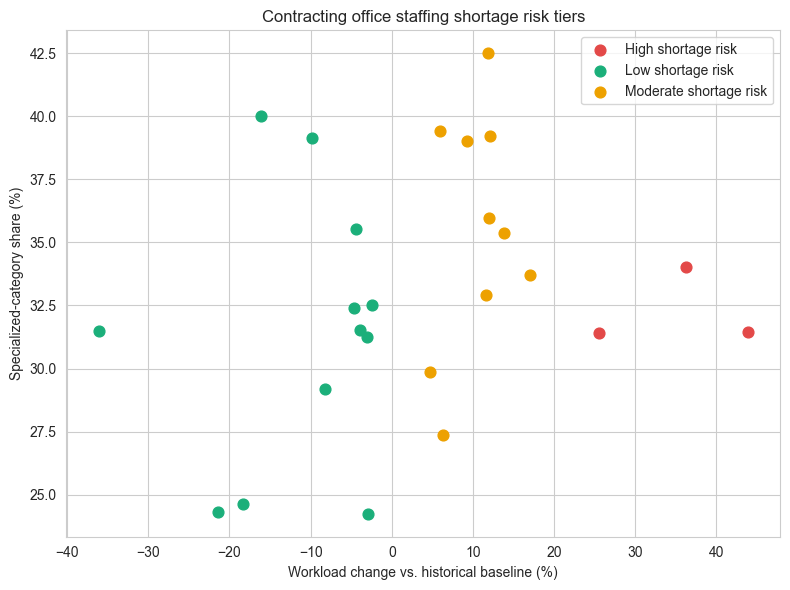

In [34]:
# Staffing shortage index: combine workload growth + specialized-category share into risk tiers via clustering
staffing_features = office_features[['workload_change_pct', 'specialized_category_share']].dropna()

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
staffing_features = staffing_features.copy()
staffing_features['cluster'] = kmeans.fit_predict(staffing_features)

# Label clusters by their mean workload_change_pct (highest = highest shortage risk)
cluster_order = staffing_features.groupby('cluster')['workload_change_pct'].mean().sort_values(ascending=False).index
tier_labels = {cluster_order[0]: 'High shortage risk', cluster_order[1]: 'Moderate shortage risk',
               cluster_order[2]: 'Low shortage risk'}
staffing_features['shortage_tier'] = staffing_features['cluster'].map(tier_labels)

staffing_summary = staffing_features.sort_values('workload_change_pct', ascending=False)
display(staffing_summary.head(10))

fig, ax = plt.subplots(figsize=(8, 6))
colors = {'High shortage risk': '#e34948', 'Moderate shortage risk': '#eda100', 'Low shortage risk': '#1baf7a'}
for tier, group in staffing_summary.groupby('shortage_tier'):
    ax.scatter(group['workload_change_pct'], group['specialized_category_share'],
               label=tier, color=colors[tier], s=60)
ax.set_xlabel('Workload change vs. historical baseline (%)')
ax.set_ylabel('Specialized-category share (%)')
ax.set_title('Contracting office staffing shortage risk tiers')
ax.legend()
plt.tight_layout()
plt.show()

---
## Phase 5 — Evaluation, validation & composite risk scoring

Combine the `Days_to_Award`, `Award_Amount`, and `Protest_Filed` models into one 0–100 risk score per acquisition, then score the live forecast pipeline with it.

In [35]:
# Final hold-out test-set metrics for the three Q4 models
X_test_input = test[numeric_features + categorical_features]

test_days_mae = mean_absolute_error(test['Days_to_Award'], days_model.predict(X_test_input))
test_award_pred = np.expm1(award_pipe.predict(X_test_input))
test_award_mape = np.mean(np.abs((test['Award_Amount'] - test_award_pred) / test['Award_Amount'])) * 100
test_protest_proba = protest_pipe.predict_proba(X_test_input)[:, 1]
test_protest_prauc = average_precision_score(test['Protest_Filed'], test_protest_proba)

print('=== Final held-out test performance ===')
print(f'Days_to_Award  MAE  : {test_days_mae:.1f} days')
print(f'Award_Amount   MAPE : {test_award_mape:.1f}%')
print(f'Protest_Filed  PR-AUC: {test_protest_prauc:.3f}')

=== Final held-out test performance ===
Days_to_Award  MAE  : 11.5 days
Award_Amount   MAPE : 10.2%
Protest_Filed  PR-AUC: 0.049


In [36]:
def composite_risk_score(df, days_pred, award_pred, protest_proba):
    days_norm = (days_pred - days_pred.min()) / (days_pred.max() - days_pred.min())
    award_norm = (np.log1p(award_pred) - np.log1p(award_pred).min()) / \
                 (np.log1p(award_pred).max() - np.log1p(award_pred).min())
    protest_norm = protest_proba  # already 0-1
    score = (0.35 * days_norm + 0.35 * award_norm + 0.30 * protest_norm) * 100
    return score.round(1)

test_days_pred = days_model.predict(X_test_input)
test_scores = composite_risk_score(test, test_days_pred, test_award_pred, test_protest_proba)

risk_table = test[['Record_ID', 'Category', 'Estimated_Value', 'Competition_Type']].copy()
risk_table['Predicted_Days_to_Award'] = test_days_pred.round(0)
risk_table['Predicted_Award_Amount'] = test_award_pred.round(0)
risk_table['Predicted_Protest_Probability'] = test_protest_proba.round(3)
risk_table['Composite_Risk_Score'] = test_scores

risk_table.sort_values('Composite_Risk_Score', ascending=False).head(10)

,Record_ID,Category,Estimated_Value,Competition_Type,Predicted_Days_to_Award,Predicted_Award_Amount,Predicted_Protest_Probability,Composite_Risk_Score
134,MODEL-001565,Construction,4892625.24,Full and Open,146.0,4965780.0,0.683,83.900002
589,MODEL-000668,Professional Services,1866494.09,Full and Open,132.0,2044986.0,0.752,76.500000
644,MODEL-000583,Pharmaceuticals,8301242.99,Full and Open,146.0,8564478.0,0.217,73.199997
553,MODEL-003329,IT Services,3454169.99,Set-Aside,108.0,3422288.0,0.822,73.000000
369,MODEL-000060,Medical/Clinical Services,11160718.25,Set-Aside,143.0,15704591.0,0.068,71.000000
605,MODEL-004644,Construction,1833324.38,Full and Open,113.0,1944084.0,0.773,70.199997
139,MODEL-003902,Medical/Clinical Services,1042345.92,Full and Open,123.0,1092410.0,0.696,68.199997
366,MODEL-003331,Pharmaceuticals,916522.65,Full and Open,111.0,930946.0,0.822,67.000000
67,MODEL-004993,IT Services,1347287.36,Full and Open,102.0,1398988.0,0.828,66.199997
319,MODEL-002357,Pharmaceuticals,1351417.17,Full and Open,113.0,1434785.0,0.693,66.099998


### Applying the models to the live forecast pipeline

Score the 2,000 planned acquisitions in `VA_Acquisition_Forecast.csv` with the trained models to get a forward-looking, model-based (rather than rule-based) priority list.

In [37]:
fc_scoring = fc_active.copy()
fc_scoring['Estimated_Value'] = fc_scoring['Estimated_Value_Midpoint']
fc_scoring['Estimated_Value_log'] = np.log1p(fc_scoring['Estimated_Value'])
fc_scoring['Set_Aside_Type'] = fc_scoring['Anticipated_Set_Aside']
fc_scoring['Competition_Type'] = fc_scoring['Anticipated_Set_Aside'].apply(
    lambda x: 'Full and Open' if x == 'Full and Open (No Set-Aside)' else 'Set-Aside')
fc_scoring['Vendor_Size'] = np.where(fc_scoring['Small_Business_Eligible'] == 'Yes',
                                      'Small Business', 'Other Than Small Business')
fc_scoring['Number_of_Offers_Received'] = modeling['Number_of_Offers_Received'].median()  # unknown pre-award, use median
fc_scoring['Requirement_Complexity_Score'] = modeling['Requirement_Complexity_Score'].median()
fc_scoring['Contracting_Office_Open_Actions'] = modeling['Contracting_Office_Open_Actions'].median()
fc_scoring['Days_Since_Requirement_Posted'] = 0

fc_scoring = fc_scoring.merge(cat_rates_train, on='Category', how='left')
fc_scoring = fc_scoring.merge(comp_rates_train, on='Competition_Type', how='left')
for col in ['Category_Historical_Protest_Rate', 'Category_Historical_OnTime_Rate',
            'Competition_Historical_Protest_Rate', 'Competition_Historical_OnTime_Rate']:
    fc_scoring[col] = fc_scoring[col].fillna(train[col].mean())

X_forecast = fc_scoring[numeric_features + categorical_features]
fc_days_pred = days_model.predict(X_forecast)
fc_award_pred = np.expm1(award_pipe.predict(X_forecast))
fc_protest_proba = protest_pipe.predict_proba(X_forecast)[:, 1]
fc_scoring['Composite_Risk_Score'] = composite_risk_score(fc_scoring, fc_days_pred, fc_award_pred, fc_protest_proba)

top_forecast_risk = fc_scoring.sort_values('Composite_Risk_Score', ascending=False)[
    ['Forecast_ID', 'Facility_Name', 'Category', 'Estimated_Value_Midpoint', 'Priority_Level',
     'Contract_Type', 'Composite_Risk_Score']
].head(15)
top_forecast_risk

,Forecast_ID,Facility_Name,Category,Estimated_Value_Midpoint,Priority_Level,Contract_Type,Composite_Risk_Score
761,FCST-000783,VISN 7 Medical Center Main,Construction,25025931.85,High,IDIQ,71.500000
473,FCST-000489,VISN 5 Medical Center North,Construction,22408721.04,Low,Cost Plus Fixed Fee,71.099998
1077,FCST-001111,VISN 4 Medical Center South,Construction,12922022.62,Low,Labor Hour,70.800003
733,FCST-000755,VISN 12 Medical Center North,IT Services,13166642.81,Low,Firm Fixed Price,70.000000
916,FCST-000945,VISN 8 Medical Center North,Medical/Clinical Services,11069839.83,Low,Time and Materials,66.500000
935,FCST-000964,VISN 12 Medical Center Main,Medical Equipment,10535340.74,Medium,Firm Fixed Price,66.000000
1482,FCST-001524,VISN 12 Medical Center Main,Professional Services,1833906.59,Low,Time and Materials,62.900002
265,FCST-000273,VISN 11 Medical Center Main,Construction,6939599.05,Low,Firm Fixed Price,62.700001
214,FCST-000221,VISN 2 Medical Center Main,Construction,7555981.54,High,Firm Fixed Price,62.700001
856,FCST-000883,VISN 3 Medical Center South,Construction,7922433.03,Low,Time and Materials,62.000000


---
## Phase 6 — Reporting summary

Consolidated answers to the four business questions, generated from the models above rather than hand-tuned rules.

In [38]:
print('=' * 70)
print('QUESTION 1 — Top acquisitions for additional oversight (by model probability)')
print('=' * 70)
oversight_input = fc_scoring.copy()
oversight_input['Is_High_Complexity'] = 1  # forecast items lack a true complexity score; treated as unknown/neutral
oversight_input['Is_Full_And_Open'] = (oversight_input['Competition_Type'] == 'Full and Open').astype(int)
X_oversight_forecast = oversight_input[oversight_features_num + oversight_features_cat].copy()
oversight_input['Oversight_Probability'] = oversight_pipe.predict_proba(X_oversight_forecast)[:, 1]
display(oversight_input.sort_values('Oversight_Probability', ascending=False)[
    ['Forecast_ID', 'Facility_Name', 'Category', 'Priority_Level', 'Oversight_Probability']].head(10))

print()
print('=' * 70)
print('QUESTION 2 — Contracting offices at risk of overload')
print('=' * 70)
display(office_features[['planned_actions_per_year', 'avg_annual_historical_awards', 'workload_change_pct']].head(8))

print()
print('=' * 70)
print('QUESTION 3 — Staffing shortage risk tiers')
print('=' * 70)
display(staffing_summary[staffing_summary['shortage_tier'] == 'High shortage risk'])

print()
print('=' * 70)
print('QUESTION 4 — Highest financial & schedule risk acquisitions')
print('=' * 70)
display(top_forecast_risk.head(10))

QUESTION 1 — Top acquisitions for additional oversight (by model probability)


,Forecast_ID,Facility_Name,Category,Priority_Level,Oversight_Probability
761,FCST-000783,VISN 7 Medical Center Main,Construction,High,0.987257
1077,FCST-001111,VISN 4 Medical Center South,Construction,Low,0.986345
473,FCST-000489,VISN 5 Medical Center North,Construction,Low,0.974706
733,FCST-000755,VISN 12 Medical Center North,IT Services,Low,0.965440
916,FCST-000945,VISN 8 Medical Center North,Medical/Clinical Services,Low,0.948175
856,FCST-000883,VISN 3 Medical Center South,Construction,Low,0.947475
935,FCST-000964,VISN 12 Medical Center Main,Medical Equipment,Medium,0.947213
214,FCST-000221,VISN 2 Medical Center Main,Construction,High,0.946827
265,FCST-000273,VISN 11 Medical Center Main,Construction,Low,0.940609
540,FCST-000557,VISN 12 Medical Center Main,IT Services,High,0.934756



QUESTION 2 — Contracting offices at risk of overload


,planned_actions_per_year,avg_annual_historical_awards,workload_change_pct
Contracting_Office,,,
Network Contracting Office (NCO) 4,35.00,24.33,43.84
Denver Acquisition and Logistics Center (DALC),31.33,23.00,36.23
SAO East,28.67,22.83,25.55
Technology Acquisition Center (TAC),28.67,24.50,17.01
Network Contracting Office (NCO) 13,27.33,24.00,13.89
Network Contracting Office (NCO) 16,26.33,23.50,12.06
Strategic Acquisition Center (SAC) - Frederick,29.67,26.50,11.95
Network Contracting Office (NCO) 14,26.67,23.83,11.89



QUESTION 3 — Staffing shortage risk tiers


,workload_change_pct,specialized_category_share,cluster,shortage_tier
Contracting_Office,,,,
Network Contracting Office (NCO) 4,43.84,31.43,2,High shortage risk
Denver Acquisition and Logistics Center (DALC),36.23,34.04,2,High shortage risk
SAO East,25.55,31.40,2,High shortage risk



QUESTION 4 — Highest financial & schedule risk acquisitions


,Forecast_ID,Facility_Name,Category,Estimated_Value_Midpoint,Priority_Level,Contract_Type,Composite_Risk_Score
761,FCST-000783,VISN 7 Medical Center Main,Construction,25025931.85,High,IDIQ,71.500000
473,FCST-000489,VISN 5 Medical Center North,Construction,22408721.04,Low,Cost Plus Fixed Fee,71.099998
1077,FCST-001111,VISN 4 Medical Center South,Construction,12922022.62,Low,Labor Hour,70.800003
733,FCST-000755,VISN 12 Medical Center North,IT Services,13166642.81,Low,Firm Fixed Price,70.000000
916,FCST-000945,VISN 8 Medical Center North,Medical/Clinical Services,11069839.83,Low,Time and Materials,66.500000
935,FCST-000964,VISN 12 Medical Center Main,Medical Equipment,10535340.74,Medium,Firm Fixed Price,66.000000
1482,FCST-001524,VISN 12 Medical Center Main,Professional Services,1833906.59,Low,Time and Materials,62.900002
265,FCST-000273,VISN 11 Medical Center Main,Construction,6939599.05,Low,Firm Fixed Price,62.700001
214,FCST-000221,VISN 2 Medical Center Main,Construction,7555981.54,High,Firm Fixed Price,62.700001
856,FCST-000883,VISN 3 Medical Center South,Construction,7922433.03,Low,Time and Materials,62.000000


### Model interpretability (SHAP)

Explains *why* the protest model flags specific acquisitions as high-risk — important for a government-oversight use case where analysts need to justify prioritization decisions.

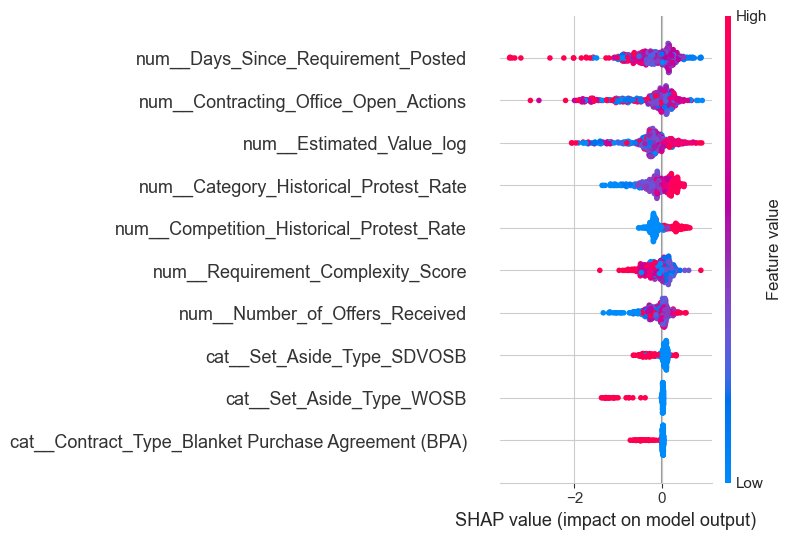

In [39]:
if HAS_SHAP and HAS_XGB:
    X_val_transformed = protest_pipe.named_steps['prep'].transform(X_val)
    feature_names = protest_pipe.named_steps['prep'].get_feature_names_out()
    explainer = shap.TreeExplainer(protest_pipe.named_steps['model'])
    shap_values = explainer.shap_values(X_val_transformed[:500])

    shap.summary_plot(shap_values, X_val_transformed[:500], feature_names=feature_names,
                       show=False, max_display=10)
    plt.tight_layout()
    plt.show()
else:
    importances = pd.Series(
        protest_pipe.named_steps['model'].feature_importances_,
        index=protest_pipe.named_steps['prep'].get_feature_names_out()
    ).sort_values(ascending=False).head(10)
    importances.plot(kind='barh', figsize=(8, 5), color='#2a78d6', title='Top 10 protest-model feature importances')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

### Model cards (summary)

| Model | Target | Best approach | Key validation metric | Test performance |
|---|---|---|---|---|
| Schedule risk | `Days_to_Award` | Gradient boosting | MAE (days) | see Phase 5 output above |
| Financial risk | `Award_Amount` | Gradient boosting (log target) | MAPE | see Phase 5 output above |
| Protest risk | `Protest_Filed` | Gradient boosting, class-weighted | PR-AUC | see Phase 5 output above |
| Oversight priority | `Needs_Oversight` | Logistic regression | PR-AUC | see Phase 4.2 output above |
| Office workload | Awards per office per year | Historical mean baseline | MAE (awards/office) | see Phase 4.3 output above |
| Staffing shortage | Shortage tier | K-means (3 clusters) | Face validity vs. workload + category mix | see Phase 4.3 output above |

**Known limitations:** all data is synthetic, so absolute metric values (e.g., 5% protest rate) reflect the data-generation logic rather than real VA procurement patterns. The office-workload and staffing-shortage components rely on only 7 years of historical data, which limits the value of more complex time-series models — a naive historical-mean baseline is a reasonable choice at this data volume. Before using this pipeline on real procurement data, re-validate every threshold (90th percentile value cutoffs, complexity-score thresholds, cluster count) against subject-matter-expert judgment.

#### Download CSV files with output ready for dashboards

In [51]:
## dashboard-ready output: save the forecast scoring table to CSV for PowerBI / Tableau / etc.
fc_scoring.to_csv('C:\\Users\\VBACOMishrR\\OneDrive - Department of Veterans Affairs\\Documents\\DataScienceGuidedCapstone\\va-acquisition-workload modifier-portfolio risk score\\data\\processed\\forecast_scoring_output.csv', index=False)

##dashboard-ready output: save the office workload scoring table to CSV for PowerBI / Tableau / etc.
office_features.to_csv('C:\\Users\\VBACOMishrR\\OneDrive - Department of Veterans Affairs\\Documents\\DataScienceGuidedCapstone\\va-acquisition-workload modifier-portfolio risk score\\data\\processed\\office_workload_scoring_output.csv', index=True)

##dashboard-ready output: save the staffing shortage scoring table to CSV for PowerBI / Tableau / etc.
staffing_summary.to_csv('C:\\Users\\VBACOMishrR\\OneDrive - Department of Veterans Affairs\\Documents\\DataScienceGuidedCapstone\\va-acquisition-workload modifier-portfolio risk score\\data\\processed\\staffing_shortage_scoring_output.csv', index=True)

##dashboard to depict the top 10 highest risk forecast acquisitions for additional oversight    
top_forecast_risk.to_csv('C:\\Users\\VBACOMishrR\\OneDrive - Department of Veterans Affairs\\Documents\\DataScienceGuidedCapstone\\va-acquisition-workload modifier-portfolio risk score\\data\\processed\\top_forecast_risk_scoring_output.csv', index=False)

##dashboard to depict the top 10 VISN forecast acquisitions for additional oversight
visn_forecast_risk = fc_scoring.groupby('VISN').agg(
    risk_score=('Composite_Risk_Score', 'mean')
).reset_index()

visn_forecast_risk.to_csv('C:\\Users\\VBACOMishrR\\OneDrive - Department of Veterans Affairs\\Documents\\DataScienceGuidedCapstone\\va-acquisition-workload modifier-portfolio risk score\\data\\processed\\visn_forecast_risk_scoring_output.csv', index=False)    



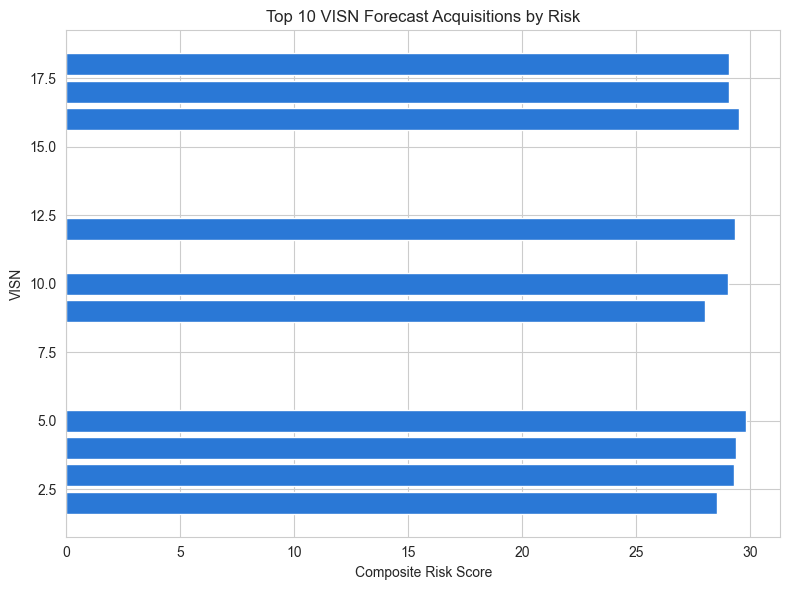

In [50]:
## Chart to depict the top 10 VISN forecast acquisitions for additional oversight
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(visn_forecast_risk.sort_values('risk_score', ascending=True).head(10)['VISN'],
        visn_forecast_risk.sort_values('risk_score', ascending=True).head(10)['risk_score'], color='#2a78d6')
ax.set_xlabel('Composite Risk Score')
ax.set_ylabel('VISN')
ax.set_title('Top 10 VISN Forecast Acquisitions by Risk')
plt.tight_layout()
